# Clutch Shot Modeling
Predict clutch shot success and rank players by clutch performance using multiple ML models.

## Setup & Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    RocCurveDisplay, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

from scipy.stats import randint, uniform

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted')
print('Libraries loaded.')

Libraries loaded.


## Load Data

In [4]:
train_df = pd.read_csv('../data/processed/engineered_clutch_train.2023.csv')
test_df  = pd.read_csv('../data/processed/engineered_clutch_test.2023.csv')

# Also load the original raw data to map player names back for rankings
raw_df = pd.read_csv('../data/processed/clutch_shot_data.2023.csv')

TARGET = 'SHOT_MADE_FLAG'

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
X_test  = test_df.drop(columns=[TARGET])
y_test  = test_df[TARGET]

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Class balance (train): {y_train.value_counts(normalize=True).round(3).to_dict()}')

Train: (1125, 25), Test: (282, 25)
Class balance (train): {0: 0.544, 1: 0.456}


## Models & Hyperparameter Grids
- **Logistic Regression** - fast and linear
- **SVM** - finds a maximum-margin decision boundary
- **Decision Tree** - Prone to overfit!
- **Random Forest** - Ensemble of trees, reduces overfitting
- **XGBoost** - Gradient boosting
- **MLP** - neural network, captures complex non-linear patterns

In [6]:
models = {
    'Logistic Regression': (
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        {
            'C': uniform(0.01, 10), # Regularization strength (inverse of regularization parameter) to control overfitting; higher values mean less regularization
            'penalty': ['l1', 'l2'], # l1 drives coefficients to 0, while l2 shrinks
            'solver': ['liblinear'] # 'liblinear' supports both 'l1' and 'l2' penalties and is suitable for small datasets
        }
    ),
    'SVM': (
        SVC(probability=True, random_state=RANDOM_STATE),
        {
            'C': uniform(0.1, 10), # Regularization parameter to control the trade-off between achieving a low training error and a low testing error; higher values mean less regularization
            'kernel': ['rbf', 'linear'],
            'gamma': ['scale', 'auto'] # gamma = 'scale' uses 1 / n_features, while 'auto' uses 1 / n_samples; controls the influence of individual training samples on the decision boundary
        }
    ),
    'Decision Tree': (
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        {
            'max_depth': randint(3, 20), # Maximum depth of the tree to control overfitting; deeper trees can capture more complex patterns but may overfit
            'min_samples_split': randint(2, 20), # Minimum number of samples required to split an internal node to control overfitting; higher values prevent the model from learning overly specific patterns
            'min_samples_leaf': randint(1, 10), # Minimum number of samples required to be at a leaf node to control overfitting; higher values prevent the model from learning overly specific patterns
            'criterion': ['gini', 'entropy'] # Function to measure the quality of a split; 'gini' is the Gini impurity, while 'entropy' is the information gain; choice can affect how the tree splits and its performance
        }
    ),
    'Random Forest': (
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        {
            'n_estimators': randint(100, 500), # Number of trees in the forest to control the ensemble size; more trees can improve performance but increase training time
            'max_depth': randint(3, 20), # Maximum depth of the tree to control overfitting; deeper trees can capture more complex patterns but may overfit
            'min_samples_split': randint(2, 10), # Minimum number of samples required to split an internal node to control overfitting; higher values prevent the model from learning overly specific patterns
            'max_features': ['sqrt', 'log2'] # Number of features to consider when looking for the best split; 'sqrt' uses the square root of the number of features, while 'log2' uses the logarithm base 2; choice can affect model performance and training time
        }
    ),
    'LightGBM': (
    LGBMClassifier(random_state=RANDOM_STATE, verbosity=-1),
    {
        'n_estimators': randint(100, 500), # Number of boosting iterations (trees) to control the ensemble size; more trees can improve performance but increase training time
        'max_depth': randint(3, 10), # Maximum depth of the tree to control overfitting; deeper trees can capture more complex patterns but may overfit
        'learning_rate': uniform(0.01, 0.3), # Learning rate to control the contribution of each tree to the final model; lower values can improve performance but require more trees and increase training time
        'subsample': uniform(0.6, 0.4), # Subsample ratio of the training instances to control overfitting; lower values can improve performance but may require more trees
        'colsample_bytree': uniform(0.6, 0.4) # Subsample ratio of columns when constructing each tree to control overfitting; lower values can improve performance but may require more trees
    }
),
    'MLP': (
        MLPClassifier(max_iter=500, random_state=RANDOM_STATE, early_stopping=True),
        {
            'hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64)], # Number of neurons in each hidden layer to control model capacity; more neurons can capture more complex patterns but may overfit
            'activation': ['relu', 'tanh'], # Activation function for the hidden layers to control non-linearity; 'relu' is generally faster and works well in most cases, while 'tanh' can capture more complex relationships but may be slower to train
            'alpha': uniform(0.0001, 0.01), # L2 regularization parameter to control overfitting; higher values mean more regularization
            'learning_rate_init': uniform(0.0001, 0.01) # Initial learning rate to control the step size at each iteration while moving toward a minimum of the loss function; lower values can improve performance but require more iterations and increase training time
        }
    )
}

print('Models defined:', list(models.keys()))

Models defined: ['Logistic Regression', 'SVM', 'Decision Tree', 'Random Forest', 'LightGBM', 'MLP']


## Hyperparameter Tuning & Cross-Validation

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) # Use stratified k-fold, recommended to maintain class balance, otherwise high variance in results can be observed

best_models = {}
cv_results   = {}

for name, (model, param_dist) in models.items(): # Iterate through each model and its corresponding hyperparameter distribution for tuning
    print(f'Tuning {name}...')
    search = RandomizedSearchCV(
        model,
        param_distributions=param_dist,
        n_iter=30, # 30 iterations, to balance thorough exploration of hyperparameter space with computational efficiency
        scoring='roc_auc',
        cv=cv,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        refit=True
    )
    search.fit(X_train, y_train)
    best_models[name] = search.best_estimator_
    cv_results[name]  = {
        'best_params': search.best_params_, # Store the best hyperparameters found for each model
        'cv_auc_mean': search.best_score_, # Store the mean CV AUC for each model
        'cv_auc_std':  search.cv_results_['std_test_score'][search.best_index_] # Store the std of CV AUC for each model
    }
    print(f'  Best CV AUC: {search.best_score_:.4f} | Params: {search.best_params_}\n') # Checkpoint to confirm tuning completed for each model and to show best CV AUC and hyperparameters found

print('Tuning complete.') 

Tuning Logistic Regression...
  Best CV AUC: 0.6942 | Params: {'C': np.float64(0.017787658410143285), 'penalty': 'l2', 'solver': 'liblinear'}

Tuning SVM...
  Best CV AUC: 0.6841 | Params: {'C': np.float64(0.44388521115218393), 'gamma': 'auto', 'kernel': 'rbf'}

Tuning Decision Tree...
  Best CV AUC: 0.6774 | Params: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 4, 'min_samples_split': 16}

Tuning Random Forest...
  Best CV AUC: 0.6936 | Params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 478}

Tuning LightGBM...
  Best CV AUC: 0.7017 | Params: {'colsample_bytree': np.float64(0.8446612641953124), 'learning_rate': np.float64(0.012119891565915222), 'max_depth': 3, 'n_estimators': 148, 'subsample': np.float64(0.8099098641033556)}

Tuning MLP...
  Best CV AUC: 0.7014 | Params: {'activation': 'tanh', 'alpha': np.float64(0.0028472179299006417), 'hidden_layer_sizes': (64, 32), 'learning_rate_init': np.float64(0.004822149251619493)}

Tuning c

## 5. Evaluate on Test Set

In [ ]:
results = []

for name, model in best_models.items(): # Iterate through each tuned model, make predictions on the test set, and calculate performance metrics to compare models on unseen data
    y_pred      = model.predict(X_test) # Get predicted class labels for the test set
    y_prob      = model.predict_proba(X_test)[:, 1] # Get predicted probabilities for the positive class (shot made) to calculate AUC

    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred), # Calculate accuracy on the test set to evaluate overall correctness of predictions
        'Precision': precision_score(y_test, y_pred), # Calculate precision on the test set to evaluate correctness of positive predictions (shot made)
        'Recall':    recall_score(y_test, y_pred), # Calculate recall on the test set to evaluate completeness of positive predictions (shot made)
        'F1':        f1_score(y_test, y_pred), # Calculate F1 score on the test set to evaluate balance between precision and recall for positive predictions (shot made)
        'AUC':       roc_auc_score(y_test, y_prob), #  Calculate AUC on the test set to evaluate model's ability to discriminate between classes (shot made vs missed) based on predicted probabilities
        'CV_AUC':    cv_results[name]['cv_auc_mean'] # Include CV AUC in results for comparison with test AUC to check for overfitting
    })

results_df = pd.DataFrame(results).sort_values('AUC', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision   Recall       F1      AUC   CV_AUC
Logistic Regression  0.656028   0.650485 0.523438 0.580087 0.662794 0.694236
           LightGBM  0.645390   0.679487 0.414062 0.514563 0.662464 0.701731
      Decision Tree  0.638298   0.641304 0.460938 0.536364 0.662464 0.677450
      Random Forest  0.652482   0.678571 0.445312 0.537736 0.660765 0.693620
                MLP  0.634752   0.606838 0.554688 0.579592 0.649046 0.701380
                SVM  0.656028   0.682353 0.453125 0.544601 0.634233 0.684136


## Visualizations
### Model Comparison

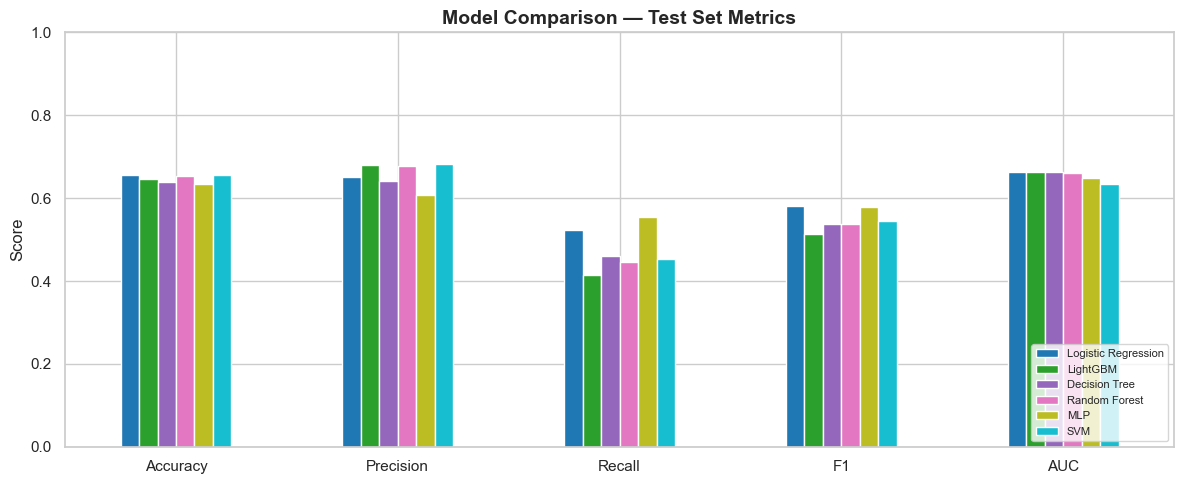

In [15]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
plot_df = results_df.set_index('Model')[metrics]

fig, ax = plt.subplots(figsize=(12, 5))
plot_df.T.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white')
ax.set_title('Model Comparison — Test Set Metrics', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right', fontsize=8)
ax.set_xticklabels(metrics, rotation=0)
plt.tight_layout()
plt.savefig('../models/model_comparison2023.png', dpi=150)
plt.show()

### ROC Curves

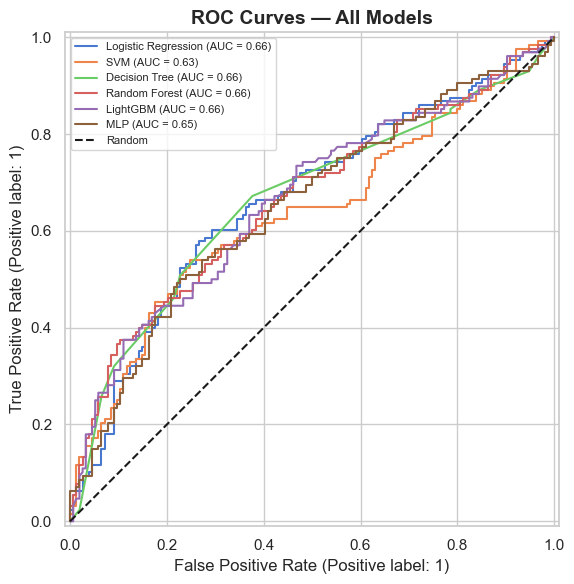

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6)) # Create a single plot for all ROC curves to compare model performance visually

for name, model in best_models.items(): # Iterate through each model and plot its ROC curve in the same plot for easy comparison
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name) # Plot ROC curve for each model using the test set predictions

ax.plot([0, 1], [0, 1], 'k--', label='Random') # Add a dashed diagonal line representing random performance for reference
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../models/roc_curves2021.png', dpi=150)
plt.show()

### Confusion Matrices

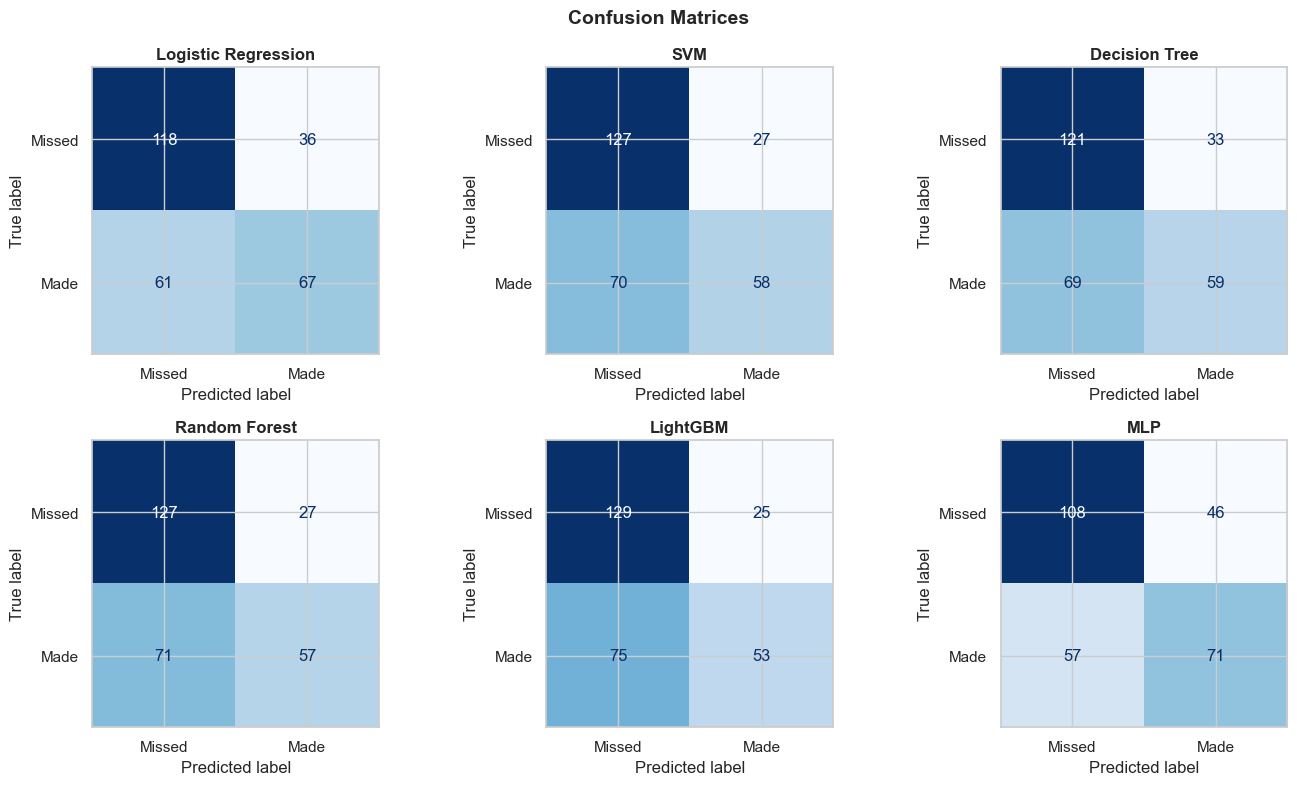

In [ ]:
n = len(best_models) # Get the number of models to determine subplot grid size
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, (name, model) in enumerate(best_models.items()): # Iterate through each model and plot its confusion matrix in a subplot
    ConfusionMatrixDisplay.from_estimator( 
        model, X_test, y_test,
        display_labels=['Missed', 'Made'],
        cmap='Blues', ax=axes[i], colorbar=False
    )
    axes[i].set_title(name, fontweight='bold')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/confusion_matrices2021.png', dpi=150)
plt.show()

### Feature Importance (Best Model)

Best model: Logistic Regression


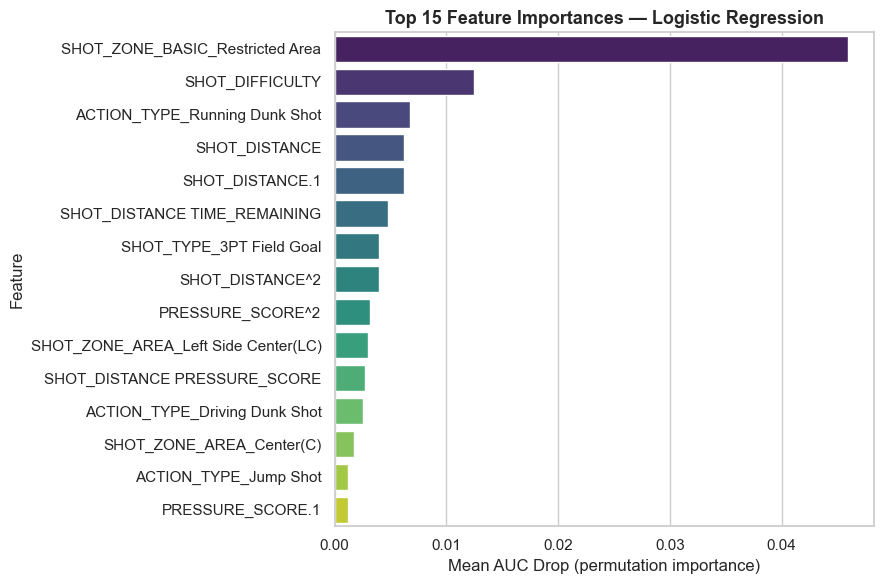

In [ ]:
best_model_name = results_df.iloc[0]['Model']
best_model      = best_models[best_model_name]
print(f'Best model: {best_model_name}')

# Use permutation importance (works for any model type)
perm = permutation_importance(
    best_model, X_test, y_test,
    scoring='roc_auc', n_repeats=10, random_state=RANDOM_STATE
)

imp_df = pd.DataFrame({ # Create a DataFrame to hold feature names and their corresponding importance scores
    'Feature':   X_test.columns,
    'Importance': perm.importances_mean
}).sort_values('Importance', ascending=False).head(15) # Sort by importance and take top 15 features for visualization

fig, ax = plt.subplots(figsize=(9, 6)) #
sns.barplot(data=imp_df, x='Importance', y='Feature', palette='viridis', ax=ax)
ax.set_title(f'Top 15 Feature Importances — {best_model_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean AUC Drop (permutation importance)')
plt.tight_layout()
plt.savefig('../models/feature_importance2021.png', dpi=150)
plt.show()

## Clutch Player Rankings
We take the best model and score every shot in the full raw dataset.
The predicted probability of making each shot is that shot's clutch difficulty.
We then rank players by how much they outperform the model's expectation.
A positive number means they beat the odds.
We filter to players with at least 20 clutch attempts for reliability.

In [19]:
# Re-engineer minimal features on raw_df to score every shot
# (same transformations as feature engineering notebook)
score_df = raw_df.copy()

score_df['PRESSURE_SCORE'] = (
    (120 - score_df['TIME_REMAINING']) * 0.6 +
    score_df['SHOT_DISTANCE'] * 0.4
)
score_df['SHOT_DIFFICULTY'] = (
    score_df['SHOT_DISTANCE'] / score_df['PERIOD']
)

player_names = score_df['PLAYER_NAME'].copy()
actual_made  = score_df[TARGET].copy()

# Drop same columns, encode, align to training columns
drop_cols = [
    'GRID_TYPE','GAME_ID','GAME_EVENT_ID','GAME_DATE','MATCHUP',
    'HTM','VTM','TEAM_NAME','TEAM_ID','PLAYER_ID','PLAYER_NAME',
    'SHOT_ATTEMPTED_FLAG','EVENT_TYPE','LOC_X','LOC_Y', TARGET
]
score_df = score_df.drop(columns=[c for c in drop_cols if c in score_df.columns])

categorical_cols = [
    'ACTION_TYPE','SHOT_ZONE_BASIC','SHOT_ZONE_AREA',
    'SHOT_TYPE','SHOT_ZONE_RANGE'
]
categorical_cols = [c for c in categorical_cols if c in score_df.columns]
score_df = pd.get_dummies(score_df, columns=categorical_cols, drop_first=True)

remaining_obj = score_df.select_dtypes(include=['object']).columns.tolist()
if remaining_obj:
    score_df = pd.get_dummies(score_df, columns=remaining_obj, drop_first=True)

bool_cols = score_df.select_dtypes(include=['bool']).columns
score_df[bool_cols] = score_df[bool_cols].astype(int)

# Align to training feature columns
score_df = score_df.reindex(columns=X_train.columns, fill_value=0)
score_df = score_df.replace([np.inf, -np.inf], np.nan).fillna(score_df.median(numeric_only=True))

print(f'Scoring {len(score_df)} shots...')
expected_prob = best_model.predict_proba(score_df)[:, 1]

ranking_df = pd.DataFrame({
    'PLAYER_NAME':   player_names.values,
    'SHOT_MADE':     actual_made.values,
    'EXPECTED_PROB': expected_prob
})

player_rankings = ranking_df.groupby('PLAYER_NAME').agg(
    attempts       =('SHOT_MADE', 'count'),
    actual_fg_pct  =('SHOT_MADE', 'mean'),
    expected_fg_pct=('EXPECTED_PROB', 'mean')
).reset_index()

player_rankings['clutch_above_expected'] = (
    player_rankings['actual_fg_pct'] - player_rankings['expected_fg_pct']
)

# Filter to players with enough attempts
MIN_ATTEMPTS = 20
qualified = player_rankings[player_rankings['attempts'] >= MIN_ATTEMPTS].copy()
qualified = qualified.sort_values('clutch_above_expected', ascending=False).reset_index(drop=True)
qualified.index += 1  # 1-based rank

print(f'\nTop 15 Most Clutch Players (min {MIN_ATTEMPTS} attempts):')
print(qualified[['PLAYER_NAME','attempts','actual_fg_pct','expected_fg_pct','clutch_above_expected']].head(15).to_string())

Scoring 1407 shots...

Top 15 Most Clutch Players (min 20 attempts):
                PLAYER_NAME  attempts  actual_fg_pct  expected_fg_pct  clutch_above_expected
1               Luka Dončić        41       0.512195         0.261591               0.250604
2             Stephen Curry       105       0.476190         0.261325               0.214865
3   Shai Gilgeous-Alexander        65       0.584615         0.371576               0.213039
4              Devin Booker        43       0.511628         0.321122               0.190505
5              Nikola Jokić        58       0.568966         0.393774               0.175192
6            Brandon Ingram        35       0.428571         0.256190               0.172382
7        Karl-Anthony Towns        30       0.433333         0.265261               0.168072
8              Jaylen Brown        36       0.361111         0.229132               0.131979
9             Pascal Siakam        50       0.560000         0.436714               0.123286
1

### 7a. Clutch Rankings Chart

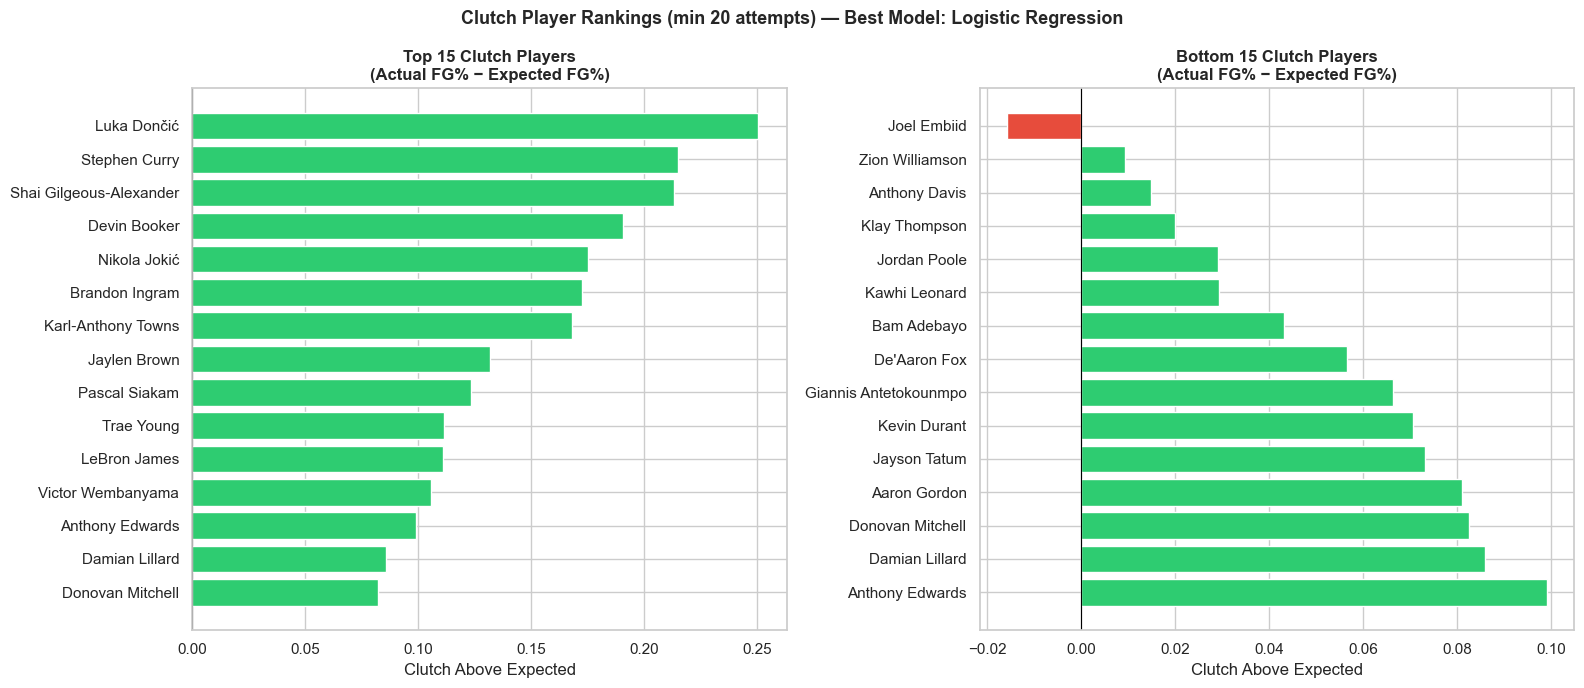

In [20]:
top15    = qualified.head(15)
bottom15 = qualified.tail(15).sort_values('clutch_above_expected')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 15
colors_top = ['#2ecc71' if v > 0 else '#e74c3c' for v in top15['clutch_above_expected']]
axes[0].barh(top15['PLAYER_NAME'], top15['clutch_above_expected'], color=colors_top)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Top 15 Clutch Players\n(Actual FG% − Expected FG%)', fontweight='bold')
axes[0].set_xlabel('Clutch Above Expected')
axes[0].invert_yaxis()

# Bottom 15
colors_bot = ['#2ecc71' if v > 0 else '#e74c3c' for v in bottom15['clutch_above_expected']]
axes[1].barh(bottom15['PLAYER_NAME'], bottom15['clutch_above_expected'], color=colors_bot)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Bottom 15 Clutch Players\n(Actual FG% − Expected FG%)', fontweight='bold')
axes[1].set_xlabel('Clutch Above Expected')
axes[1].invert_yaxis()

plt.suptitle(f'Clutch Player Rankings (min {MIN_ATTEMPTS} attempts) — Best Model: {best_model_name}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/clutch_player_rankings2023.png', dpi=150)
plt.show()

### 7b. Actual vs Expected FG% Scatter

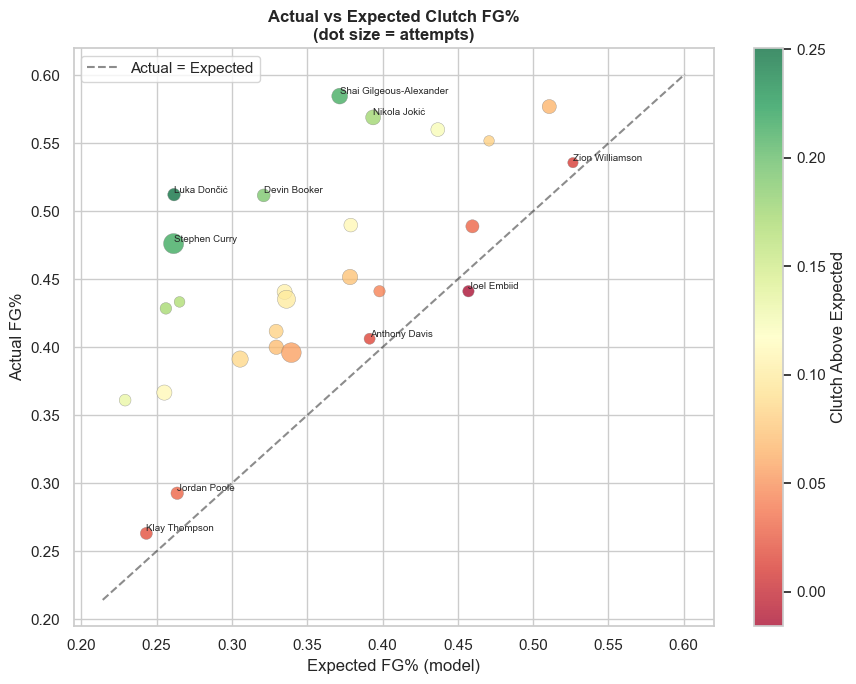

In [21]:
fig, ax = plt.subplots(figsize=(9, 7))

sc = ax.scatter(
    qualified['expected_fg_pct'],
    qualified['actual_fg_pct'],
    c=qualified['clutch_above_expected'],
    cmap='RdYlGn', s=qualified['attempts'] * 2,
    alpha=0.75, edgecolors='grey', linewidth=0.3
)

lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k--', alpha=0.5, label='Actual = Expected')

# Label top 5 and bottom 5
for _, row in pd.concat([qualified.head(5), qualified.tail(5)]).iterrows():
    ax.annotate(row['PLAYER_NAME'],
                (row['expected_fg_pct'], row['actual_fg_pct']),
                fontsize=7, ha='left', va='bottom')

plt.colorbar(sc, ax=ax, label='Clutch Above Expected')
ax.set_xlabel('Expected FG% (model)')
ax.set_ylabel('Actual FG%')
ax.set_title('Actual vs Expected Clutch FG%\n(dot size = attempts)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../models/actual_vs_expected2023.png', dpi=150)
plt.show()

## 8. Save Rankings

In [14]:
qualified.to_csv('../data/processed/clutch_player_rankings.2023.csv')
results_df.to_csv('../data/processed/model_results.2023.csv', index=False)
print('Saved rankings and model results.')

Saved rankings and model results.
